# Установка библиотек

In [ ]:
!pip install --upgrade pip
!pip install h5py pandas numpy scikit-learn torch requests boto3 tqdm jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 15.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [boto3]


In [ ]:
# !git clone https://github.com/google-research/timesfm.git
# %cd timesfm
# !pip install -r requirements.txt
# !pip install torch

In [ ]:
!git clone https://github.com/google-research/timesfm.git
%cd timesfm
!sed -i "s/python_requires='>=3.10, <3.12',/python_requires='>=3.10',/" setup.py
!pip install -e ".[torch]"
!pip install -r requirements.txt
%cd ..

fatal: destination path 'timesfm' already exists and is not an empty directory.
/content/timesfm
sed: can't read setup.py: No such file or directory
Obtaining file:///content/timesfm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for timesfm (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-0.editable-py3-none-any.whl size=7241 sha256=953ec67f666024e9ecf31563cbd580c82d26a95ac8ed2ac4cb4600fb757e99f6
  Stored in directory: /tmp/pip-ephem-wheel-cache-icq5yrfq/wheels/ac/ab/a9/bb266c6b9fb1045c9820bc505744d7d341b734de0fee7fae41
Successfully built timesfm
  Attempting uninstall: timesfm
    Found existing installation: timesfm 2.0.0
    Uninstalling timesfm-2.0.0:
      Successfully uninstalled timesfm-2.0.0
/content


In [ ]:
%cd timesfm
!sed -i "s/python_requires='>=3.10, <3.12',/python_requires='>=3.10',/" setup.py
!pip install -e ".[torch]"
%cd ..

# Прогнозирование

## импорты

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
import h5py, boto3, gc, re, requests
from io import BytesIO
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, mean_squared_error, mean_absolute_error
import json
import traceback
from timesfm import TimesFM_2p5_200M_torch
import warnings
warnings.filterwarnings('ignore')

## локальные данные

In [ ]:
class MamkaLoader:
    def __init__(self, endpoint_url, access_key, secret_key, bucket="mamka"):
        self.bucket = bucket
        self.s3 = boto3.client(
            "s3",
            endpoint_url=endpoint_url,
            aws_access_key_id=access_key,
            aws_secret_access_key=secret_key
        )

    def _list_files(self, prefix):
        files, token = [], None
        while True:
            kwargs = {"Bucket": self.bucket, "Prefix": prefix}
            if token:
                kwargs["ContinuationToken"] = token
            res = self.s3.list_objects_v2(**kwargs)
            files += [obj["Key"] for obj in res.get("Contents", [])]
            if res.get("IsTruncated"):
                token = res.get("NextContinuationToken")
            else:
                break
        return files

    def _extract_time(self, key):
        match = re.search(r'(\d{2}:\d{2}:\d{2})', key)
        return match.group(1) if match else "00:00:00"

    def _read_h5(self, key):
        obj = self.s3.get_object(Bucket=self.bucket, Key=key)
        file_bytes = obj["Body"].read()
        data = {}
        with h5py.File(BytesIO(file_bytes), "r") as f:
            def extract(name, obj):
                if isinstance(obj, h5py.Dataset):
                    try:
                        val = np.nan_to_num(obj[()])
                        data[name] = val
                    except:
                        pass
            f.visititems(extract)
        return data

    def _to_dataframe(self, data, start_dt):
        frames = []
        for key, val in data.items():
            col = key.replace("/", "_").replace("-", "_")
            try:
                val = np.array(val, dtype=np.float32)
            except:
                continue
            if val.ndim > 1:
                val = val.reshape(-1)
            if len(val) == 0:
                continue
            df = pd.DataFrame({col: val})
            df["time_idx"] = np.arange(len(val))
            frames.append(df)
        if not frames:
            return pd.DataFrame()
        result = frames[0]
        for df in frames[1:]:
            result = pd.merge(result, df, on="time_idx", how="outer")
        result["timestamp"] = start_dt + pd.to_timedelta(result["time_idx"], unit="s")
        return result.drop(columns=["time_idx"])

## pipeline

In [ ]:
class WeatherPipeline:
    def __init__(self):
        self.scaler = StandardScaler()
        self.fixed_columns = None

    def preprocess(self, df):
        df = df.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp').sort_index()
        df = df.select_dtypes(include=np.number)
        df = df.resample("1min").mean()
        df = df.interpolate().ffill().bfill()
        df = df.fillna(0)
        return df

    def create_features(self, df):
        df = df.copy()
        for col in df.columns:
            df[f"{col}_ma5"] = df[col].rolling(5).mean()
            df[f"{col}_diff"] = df[col].diff()
        df = df.fillna(0)
        return df

    def create_target(self, df):
        df = df.copy()

        rain = [c for c in df.columns if "precip" in c.lower()]
        wind = [c for c in df.columns if "wind" in c.lower()]

        rain_sig = df[rain].max(axis=1) if rain else pd.Series(0, index=df.index)
        wind_sig = df[wind].max(axis=1) if wind else pd.Series(0, index=df.index)

        # нормализация
        def normalize(x):
            if x.max() - x.min() < 1e-6:
                return pd.Series(0, index=x.index)
            return (x - x.min()) / (x.max() - x.min())

        rain_norm = normalize(rain_sig)
        wind_norm = normalize(wind_sig)

        # итоговый target
        df["target"] = 0.5 * rain_norm + 0.5 * wind_norm

        print(" target stats:")
        print(df["target"].describe())

        return df

    def remove_leakage(self, df):
        df = df.copy()
        wind_cols = [c for c in df.columns if 'wind' in c.lower()]
        for col in wind_cols:
            df[f"{col}_lag1"] = df[col].shift(1)
        df = df.drop(columns=wind_cols, errors='ignore')
        df = df.fillna(0)
        return df

    def get_feature_columns(self, df):
        """Определяем фиксированный список колонок на основе первых данных"""
        X = df.drop(columns=['target'], errors='ignore')
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

        non_const = X.columns[X.std() > 1e-6]
        return list(non_const)

    def fit_scaler(self, df, fixed_columns=None):
        """Fit scaler с фиксированными колонками"""
        X = df.drop(columns=['target'], errors='ignore')
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

        if fixed_columns is not None:
            missing_cols = set(fixed_columns) - set(X.columns)
            for col in missing_cols:
                X[col] = 0
            X = X[fixed_columns]
        else:
            non_const = X.columns[X.std() > 1e-6]
            self.fixed_columns = list(non_const)
            X = X[self.fixed_columns]

        self.scaler.fit(X)
        return X.columns.tolist()

    def transform(self, df):
        """Transform с фиксированными колонками"""
        X = df.drop(columns=['target'], errors='ignore')
        y = df['target'].values

        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

        if self.fixed_columns is not None:
            for col in self.fixed_columns:
                if col not in X.columns:
                    X[col] = 0
            X = X[self.fixed_columns]

        X_scaled = self.scaler.transform(X)
        return X_scaled.astype(np.float32), y.astype(np.float32)

## глобальные данные

In [ ]:
class GlobalWeatherLoader:
    def __init__(self, lat, lon):
        self.lat = lat
        self.lon = lon

    def load(self, start, end):
        url = (
            f"https://api.open-meteo.com/v1/forecast"
            f"?latitude={self.lat}&longitude={self.lon}"
            f"&hourly=temperature_2m,wind_speed_10m,pressure_msl,precipitation"
            f"&start_date={start}&end_date={end}"
        )
        try:
            resp = requests.get(url, timeout=10)
            resp.raise_for_status()
            data = resp.json()
            if "hourly" not in data:
                print(f"! Warning: 'hourly' not in API response for {start} to {end}")
                return pd.DataFrame()
            df = pd.DataFrame({
                "timestamp": data["hourly"]["time"],
                "g_temp": data["hourly"]["temperature_2m"],
                "g_wind": data["hourly"]["wind_speed_10m"],
                "g_pressure": data["hourly"]["pressure_msl"],
                "g_precip": data["hourly"]["precipitation"]
            })
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df = df.set_index("timestamp")
            return df.resample("1min").interpolate()
        except Exception as e:
            print(f"! Failed to load global data: {e}")
            return pd.DataFrame()

def check_global_data(start_date, end_date, lat=52.37, lon=4.9):
    dates = pd.date_range(start=start_date, end=end_date)
    loader = GlobalWeatherLoader(lat, lon)
    available_days = []
    missing_days = []
    for d in dates:
        df = loader.load(d.strftime("%Y-%m-%d"), d.strftime("%Y-%m-%d"))
        if df.empty:
            missing_days.append(d.date())
            print(f"! Global data missing for {d.date()}")
        else:
            available_days.append(d.date())
            print(f" Global data available for {d.date()} ({len(df)} rows)")
    print(f"\nSummary: {len(available_days)} days available, {len(missing_days)} days missing")
    return available_days, missing_days

## foundation

In [ ]:
class TimesFMExtractor:
    def __init__(self):
        self.model = TimesFM_2p5_200M_torch()
        self.cache = {}

    def transform(self, series):
        # Обработка NaN/inf
        series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
        key = hash(series.tobytes())

        if key in self.cache:
            return self.cache[key]

        x = series[:, 0].astype(np.float32).reshape(1, -1)
        try:
            forecast = self.model.forecast(x)[0]
            forecast = np.nan_to_num(forecast, nan=0.0)
        except:
            forecast = np.zeros(1)

        self.cache[key] = forecast
        return forecast.astype(np.float32)

## модель

In [ ]:
class AttentionFusionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.attn = nn.Linear(hidden_size, 1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attn(out), dim=1)
        context = (attn_weights * out).sum(dim=1)
        return self.fc(context)

## генератор

In [ ]:
def batch_generator(loader, pipeline, start_date, end_date, window=64, fit_scaler_first=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    timesfm = TimesFMExtractor()
    dates = pd.date_range(start=start_date, end=end_date)
    global_loader = GlobalWeatherLoader(lat=52.37, lon=4.9)

    if fit_scaler_first:
        print(" Fitting scaler on first file")
        first_df = None
        for cur in dates:
            prefix = cur.strftime("%Y/%m/%d/")
            files = loader._list_files(prefix)
            for key in files:
                if not key.endswith(".h5"): continue
                try:
                    raw = loader._read_h5(key)
                    time_str = loader._extract_time(key)
                    start_dt = datetime.strptime(prefix[:10] + " " + time_str, "%Y/%m/%d %H:%M:%S")
                    df = loader._to_dataframe(raw, start_dt)
                    if df.empty: continue

                    df = pipeline.preprocess(df)
                    df = pipeline.create_features(df)
                    df = pipeline.create_target(df)
                    df = pipeline.remove_leakage(df)

                    pipeline.fit_scaler(df, fixed_columns=None)
                    first_df = df
                    break
                except Exception as e:
                    print(f" ! Error in fit_scaler: {e}")
                    continue
            if first_df is not None:
                break

        if first_df is None:
            raise RuntimeError("! Не удалось выполнить fit_scaler - нет данных!")
        print(f" Scaler fitted with {len(pipeline.fixed_columns)} features")

    # Основной цикл генерации батчей
    for cur in dates:
        prefix = cur.strftime("%Y/%m/%d/")
        files = loader._list_files(prefix)
        g_df = global_loader.load(cur.strftime("%Y-%m-%d"), cur.strftime("%Y-%m-%d"))
        if g_df.empty:
            print(f"! Skipping {cur.date()} due to missing global data")
            continue

        for key in files:
            if not key.endswith(".h5"): continue
            try:
                raw = loader._read_h5(key)
                time_str = loader._extract_time(key)
                start_dt = datetime.strptime(prefix[:10] + " " + time_str, "%Y/%m/%d %H:%M:%S")
                df = loader._to_dataframe(raw, start_dt)
                if df.empty: continue

                df = pipeline.preprocess(df)
                df = pipeline.create_features(df)
                df = pipeline.create_target(df)
                df = pipeline.remove_leakage(df)

                # Добавляем глобальные данные
                df = df.merge(g_df, left_index=True, right_index=True, how='left')
                df = df.ffill().bfill().fillna(0)

                # Проверяем наличие обоих классов
                if len(df["target"].unique()) < 2:
                    print(f"! Skipping {key} - only one class in target")
                    continue

                # Transform с фиксированными колонками
                X, y = pipeline.transform(df)

                # Проверяем на NaN/inf
                if np.any(np.isnan(X)) or np.any(np.isinf(X)):
                    print(f"! Skipping {key} - X contains NaN/inf")
                    continue

                if len(X) < window + 1:
                    continue

                indices = np.arange(len(X) - window)
                np.random.shuffle(indices)
                for start_idx in indices[:100]:  # количество батчей
                    x_win = X[start_idx:start_idx+window]
                    y_win = y[start_idx+window]
                    emb = timesfm.transform(x_win)
                    emb = np.repeat(emb.reshape(1, -1), window, axis=0)
                    x_win = np.concatenate([x_win, emb], axis=1)

                    # Последняя проверка
                    if np.any(np.isnan(x_win)) or np.any(np.isinf(x_win)):
                        continue

                    yield torch.tensor(x_win).unsqueeze(0).to(device), torch.tensor([[y_win]]).to(device)

                del df, X, y
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Error processing {key}: {e}")
                traceback.print_exc()

## обучение

In [ ]:
def train_model(loader, start_date, end_date, pipeline, window=64, epochs=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Проверяем генератор на наличие данных
    gen = batch_generator(loader, pipeline, start_date, end_date, window, fit_scaler_first=True)
    sample_count = 0
    sample_x = None
    for x, y in gen:
        sample_x = x
        sample_count += 1
        if sample_count >= 1:
            break

    if sample_x is None:
        raise RuntimeError("! Нет доступных данных для обучения. Проверьте локальные и глобальные данные.")

    input_size = sample_x.shape[2]
    print(f" Model input size: {input_size}")

    model = AttentionFusionLSTM(input_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.SmoothL1Loss()

    for epoch in range(epochs):
        gen = batch_generator(loader, pipeline, start_date, end_date, window, fit_scaler_first=False)
        epoch_loss = 0
        count = 0

        for x_batch, y_batch in gen:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            count += 1

            if count % 10 == 0:
                print(f"  Batch {count}, loss: {loss.item():.4f}")

        if count > 0:
            print(f"Epoch {epoch+1}/{epochs} avg loss: {epoch_loss / count:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} - No batches processed")
            break

    return model

## evaluation

In [ ]:
def evaluate_model(model, loader, pipeline, start_date, end_date, window=64):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_true, all_pred = [], []

    gen = batch_generator(loader, pipeline, start_date, end_date, window, fit_scaler_first=False)
    with torch.no_grad():
        for x_batch, y_batch in gen:
            logits = model(x_batch)
            pred = logits
            all_true.extend(y_batch.cpu().numpy().flatten())
            all_pred.extend(pred.cpu().numpy().flatten())

    if len(all_true) == 0:
        print("! No predictions generated!")
        return {"mse": 0.0, "mae": 0.0, "auc": 0.0}, pd.DataFrame()

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    # Проверяем на NaN
    if np.any(np.isnan(all_pred)):
        print("! NaN detected in predictions, replacing with 0")
        all_pred = np.nan_to_num(all_pred, nan=0.0)

    # Метрики для continuous target
    mse = mean_squared_error(all_true, all_pred)
    mae = mean_absolute_error(all_true, all_pred)

    # AUC через мягкую бинаризацию
    binary_true = (all_true > 0.5).astype(int)
    binary_pred = (all_pred > 0.5).astype(int)

    # AUC для одного класса
    if len(np.unique(binary_true)) < 2:
        auc_score = 0.5
        print(f"! Only one class in true labels, AUC set to 0.5")
    else:
        try:
            auc_score = roc_auc_score(binary_true, all_pred)
        except Exception as e:
            print(f"! Error computing AUC: {e}")
            auc_score = 0.5

    metrics = {"mse": float(mse), "mae": float(mae), "auc": float(auc_score)}

    # Вычисляем R^2
    from sklearn.metrics import r2_score
    r2 = r2_score(all_true, all_pred)
    print(f" R^2 Score: {r2:.4f}")

    # Вычисляем baseline
    baseline = np.mean(all_true)
    baseline_pred = np.full_like(all_true, baseline)
    baseline_mse = mean_squared_error(all_true, baseline_pred)
    baseline_mae = mean_absolute_error(all_true, baseline_pred)
    print(f" Baseline (mean) MSE: {baseline_mse:.4f}, MAE: {baseline_mae:.4f}")
    print(f" Model improvement vs baseline: {(1 - mse/baseline_mse)*100:.1f}%")

    # Добавляем в метрики
    metrics["r2"] = float(r2)
    metrics["baseline_mse"] = float(baseline_mse)
    metrics["improvement_pct"] = float((1 - mse/baseline_mse)*100)

    print(f"Final metrics: MSE={mse:.4f}, MAE={mae:.4f}, AUC={auc_score:.4f}")

    with open("metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    df_preds = pd.DataFrame({"true": all_true, "pred": all_pred})
    df_preds.to_csv("predictions.csv", index=False)

    # визуализация
    try:
        plt.figure(figsize=(15, 5))

        # График 1: True vs Predicted scatter plot с идеальной линией
        plt.subplot(1, 3, 1)
        plt.scatter(all_true[:1000], all_pred[:1000], alpha=0.3, s=10)
        plt.xlabel("True Values", fontsize=10)
        plt.ylabel("Predicted Values", fontsize=10)
        plt.title("True vs Predicted", fontsize=12)
        min_val = min(all_true.min(), all_pred.min())
        max_val = max(all_true.max(), all_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, linewidth=2, label='Ideal')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # График 2: Предсказания vs реальные значения по времени
        plt.subplot(1, 3, 2)
        plt.plot(all_pred[:min(500, len(all_pred))], label="Predicted", alpha=0.7, linewidth=1)
        plt.plot(all_true[:min(500, len(all_true))], label="True", alpha=0.7, linewidth=1)
        plt.xlabel("Samples", fontsize=10)
        plt.ylabel("Intensity", fontsize=10)
        plt.title("Predictions vs True over Time", fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)

        # График 3: ROC Curve с подписями
        plt.subplot(1, 3, 3)
        if len(np.unique(binary_true)) > 1:
            fpr, tpr, _ = roc_curve(binary_true, all_pred)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        plt.xlabel("False Positive Rate", fontsize=10)
        plt.ylabel("True Positive Rate", fontsize=10)
        plt.title("ROC Curve", fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("evaluation_plots.png", dpi=300, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"! Error during visualization: {e}")
        traceback.print_exc()

    print("\n DEBUG INFO:")
    print(f"True min/max: {all_true.min():.4f} / {all_true.max():.4f}")
    print(f"Pred min/max: {all_pred.min():.4f} / {all_pred.max():.4f}")
    print(f"NaN in pred: {np.isnan(all_pred).sum()}")
    print(f"Unique true values: {len(np.unique(all_true))}")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")

    return metrics, df_preds

## запуск

Выходные данные были обрезаны до нескольких последних строк (5000).
min       0.000000
25%       0.000000
50%       0.250000
75%       0.250000
max       0.500000
Name: target, dtype: float64
 target stats:
count    79.000000
mean      0.743671
std       0.211734
min       0.000000
25%       0.500000
50%       0.750000
75%       1.000000
max       1.000000
Name: target, dtype: float64
 target stats:
count    66.00000
mean      0.69697
std       0.26134
min       0.00000
25%       0.50000
50%       0.50000
75%       1.00000
max       1.00000
Name: target, dtype: float64
 target stats:
count    79.000000
mean      0.755274
std       0.157517
min       0.000000
25%       0.666667
50%       0.833333
75%       0.833333
max       1.000000
Name: target, dtype: float64
 target stats:
count    66.000000
mean      0.700758
std       0.197190
min       0.000000
25%       0.500000
50%       0.750000
75%       0.750000
max       1.000000
Name: target, dtype: float64
 target stats:
count    79.00000

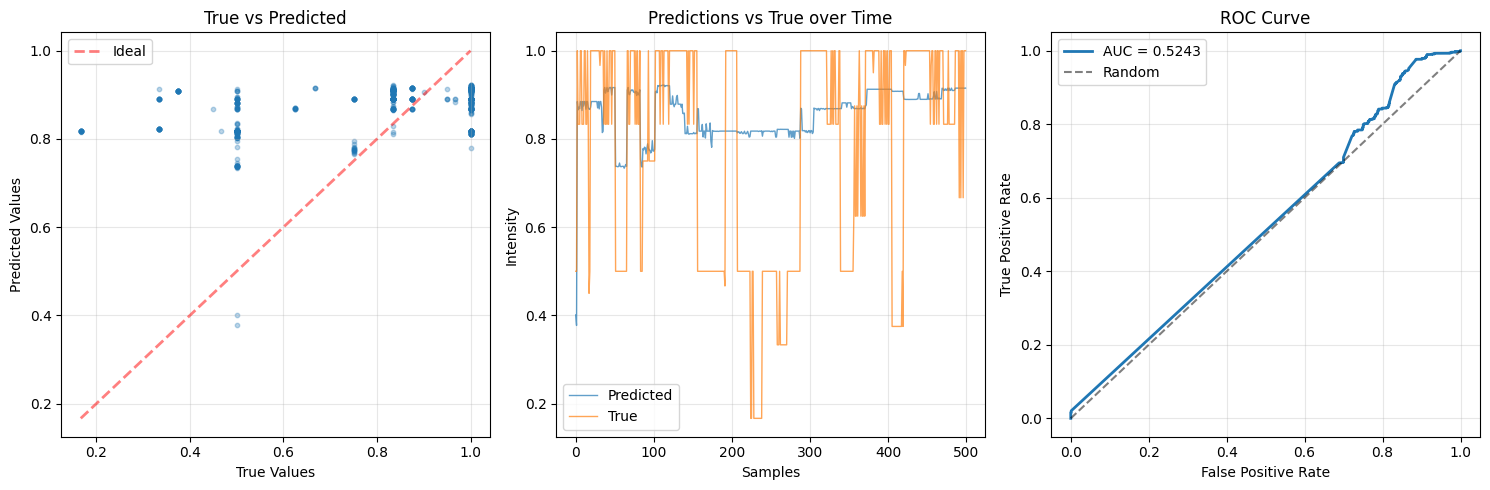

Выходные данные были обрезаны до нескольких последних строк (5000).
min       0.000000
25%       0.000000
50%       0.250000
75%       0.250000
max       0.500000
Name: target, dtype: float64
 target stats:
count    79.000000
mean      0.743671
std       0.211734
min       0.000000
25%       0.500000
50%       0.750000
75%       1.000000
max       1.000000
Name: target, dtype: float64
 target stats:
count    66.00000
mean      0.69697
std       0.26134
min       0.00000
25%       0.50000
50%       0.50000
75%       1.00000
max       1.00000
Name: target, dtype: float64
 target stats:
count    79.000000
mean      0.755274
std       0.157517
min       0.000000
25%       0.666667
50%       0.833333
75%       0.833333
max       1.000000
Name: target, dtype: float64
 target stats:
count    66.000000
mean      0.700758
std       0.197190
min       0.000000
25%       0.500000
50%       0.750000
75%       0.750000
max       1.000000
Name: target, dtype: float64
 target stats:
count    79.00000

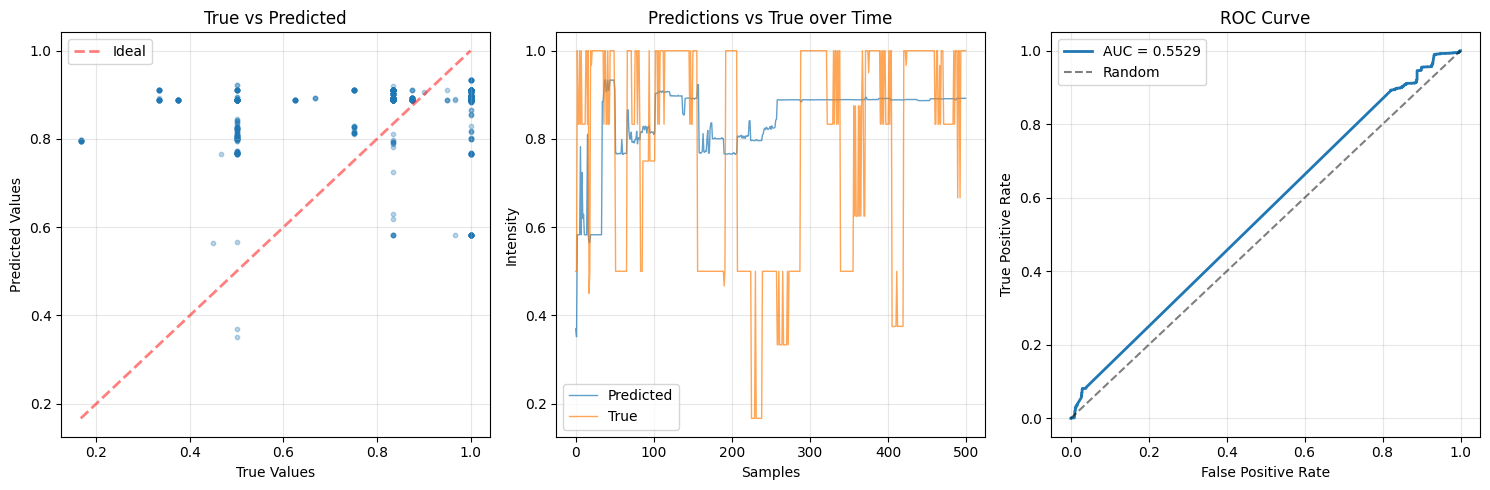


 DEBUG INFO:
True min/max: 0.1667 / 1.0000
Pred min/max: 0.3516 / 0.9338
NaN in pred: 0
Unique true values: 27
MSE: 0.044496
MAE: 0.153425


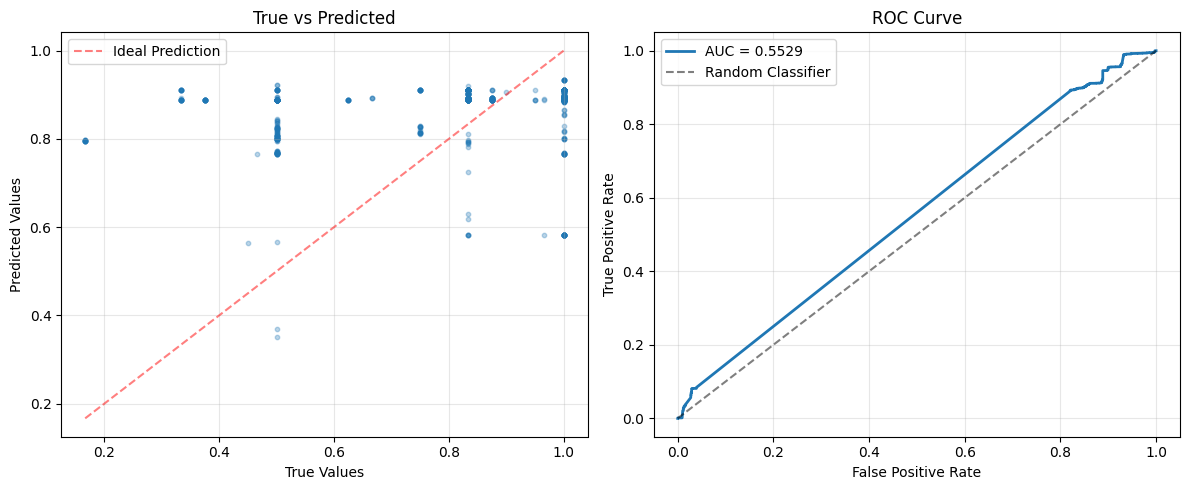


 Training and evaluation completed!
  Final metrics: {'mse': 0.0444963164627552, 'mae': 0.15342533588409424, 'auc': 0.5528713549349197, 'r2': -0.03190195560455322, 'baseline_mse': 0.04312068223953247, 'improvement_pct': -3.1901958683797638}


In [ ]:
if __name__ == "__main__":
    # Настройки
    START_DATE = "2026-03-02"
    END_DATE = "2026-03-16"
    WINDOW = 64
    EPOCHS = 2

    # Инициализация
    loader = MamkaLoader(
        endpoint_url="http://weather.okpars.com:9000",
        access_key="RO_User",
        secret_key="vy6ogWbguest"
    )
    pipeline = WeatherPipeline()

    # Проверяем глобальные данные
    available_days, missing_days = check_global_data(START_DATE, END_DATE, lat=52.37, lon=4.9)
    if not available_days:
        raise RuntimeError("! Нет доступных глобальных данных для выбранного периода!")

    # Обучение модели
    try:
        model = train_model(loader, START_DATE, END_DATE, pipeline, window=WINDOW, epochs=EPOCHS)

        # Оценка
        metrics, df_preds = evaluate_model(model, loader, pipeline, START_DATE, END_DATE, window=WINDOW)

        print("\n Training and evaluation completed!")
        print(f"Final metrics saved to metrics.json")
        print(f"Predictions saved to predictions.csv")

    except Exception as e:
        print(f"\n ! Error: {e}")
        traceback.print_exc()
    # Визуализация
    try:
        model = train_model(loader, START_DATE, END_DATE, pipeline, window=WINDOW, epochs=EPOCHS)

        # Оценка
        metrics, df_preds = evaluate_model(model, loader, pipeline, START_DATE, END_DATE, window=WINDOW)

        all_true = df_preds["true"].values
        all_pred = df_preds["pred"].values

        # Создаем бинарные метки для ROC
        binary_true = (all_true > 0.5).astype(int)

        plt.figure(figsize=(12,5))

        # График 1: Scatter с идеальной линией
        plt.subplot(1,2,1)
        plt.scatter(all_true[:1000], all_pred[:1000], alpha=0.3, s=10)
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title("True vs Predicted")
        # Идеальная линия
        min_val = min(all_true.min(), all_pred.min())
        max_val = max(all_true.max(), all_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Ideal Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # График 2: ROC Curve
        plt.subplot(1,2,2)
        if len(np.unique(binary_true)) > 1:
            fpr, tpr, _ = roc_curve(binary_true, all_pred)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
        plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Classifier')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("final_evaluation.png", dpi=300, bbox_inches='tight')
        plt.show()

        print("\n Training and evaluation completed!")
        print(f"  Final metrics: {metrics}")

    except Exception as e:
        print(f"\n ! Error: {e}")
        traceback.print_exc()